### **Training the Classification model** : 

##### **models** : 
- Xgboost 
- lightgbm 
- catboost 

##### **evaluation metrics**: 
- accuracy 
- recall 
- F1_score 
- pecision 


##### **01- Importing the libraries and packages** 

In [22]:
import pandas as pd
import seaborn as sns 
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.model_selection import (
                            train_test_split,
                            StratifiedKFold,
                            cross_val_score,
                            cross_validate,
                            GridSearchCV,
                            RandomizedSearchCV
                            )
from sklearn.metrics import (classification_report ,
                            confusion_matrix,
                            roc_curve,
                            accuracy_score,
                            f1_score,
                            precision_recall_curve,
                            precision_score, recall_score)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import optuna

import time
import joblib 
import wandb as wb 
from dotenv import load_dotenv, find_dotenv
import os

sns.set_theme('paper')
sns.set_style('ticks')

import warnings 
warnings.filterwarnings("ignore",    category=DeprecationWarning,
    module="wandb.analytics.sentry")

/home/yassine/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### **02- data preprocessing** 

In [2]:
df = pd.read_csv('../Data/BEED_Data.csv')
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0


In [3]:
X, y = df.iloc[:,:-1],df.iloc[:,-1]

x_train,x_test,y_train,y_test = train_test_split(X, y,
                                        test_size=0.3,
                                        stratify=y,
                                        random_state=42)

print("x train :",x_train.shape," | y train :",y_train.shape)
print("y test :",x_test.shape,"  | y test:",y_test.shape)


x train : (5600, 16)  | y train : (5600,)
y test : (2400, 16)   | y test: (2400,)


In [4]:
models = {
    "Xgb":XGBClassifier(random_state=42),
    "Lgr":LogisticRegression(random_state=42,max_iter=100),
    "Lgb":LGBMClassifier(random_state=42,verbosity=-1),
    "Cat":CatBoostClassifier(random_state=42,verbose=False),
    "Rf":RandomForestClassifier(random_state=42)
}

In [5]:
load_dotenv(find_dotenv())
WB_KEY = os.getenv("WANDB_KEY")

wb.login(WB_KEY)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/yassine/.netrc
wandb: Currently logged in as: yassinedatascientist001 (yassinedatascientist001-datalab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

##### **03. Model training : baseline**

In [6]:
PROJECT_NAME = "Epeliptic_seizure_classification"
GROUP_NAME = "Baseline-comparison-v1"
CLASS_NAMES=["healthy","generalize","focal","event"]
results = []

for name , model in models.items():
    # initialisation of the run 
    run = wb.init(
            project=PROJECT_NAME,
            name=name,
            group=GROUP_NAME,
            job_type="train",
            config={
                "model_type":name,
                **model.get_params()
            },
            reinit=True,
            settings=wb.Settings(silent=True, quiet=True, console="off")
    )

    #Training 
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)

    # logging the model as .joblib file 



    #evaluation
    metrics = {
        "f1" : f1_score(y_test,y_pred,average="weighted"),
        "accuracy" : accuracy_score(y_test,y_pred),
        "precision_weighted": precision_score(y_test, y_pred, average="weighted"),
        "recall_weighted": recall_score(y_test, y_pred, average="weighted")
                }

    model_path = f"{name}_model.joblib"
    joblib.dump(model,model_path)

    artifact = wb.Artifact(
        name=f"{name}_model",
        type="model",
        description=f"{name} model baseline classifier",
        metadata=metrics
        )
    
    # logging the model as Artifact
    artifact.add_file(model_path)
    run.log_artifact(artifact)

    wb.log(metrics)

    results.append({
        "model":name,
        **metrics
    })
    wb.finish()
    
summary_run = wb.init(
    project=PROJECT_NAME,
    name="summary",
    group=GROUP_NAME,
    job_type="comparison"
)
table = wb.Table(dataframe=pd.DataFrame(results))
wb.log({"model_comparison": table})
summary_run.finish()

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.
wandb: WARNING Artifact "Xgb_model" already exists with the same content. No new version will be created.
/home/yassine/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
wandb: WARNING Artifact "Lgr_model" already exists with the same content. No new version will be created.
wandb: WARNING Artifact "Lgb_model" already exists with the same content

In [11]:

model_bench = pd.DataFrame(
    results
    )
model_bench


,model,f1,accuracy,precision_weighted,recall_weighted
0,Xgb,0.964266,0.964167,0.964545,0.964167
1,Lgr,0.475152,0.468333,0.500607,0.468333
2,Lgb,0.966740,0.966667,0.966861,0.966667
3,Cat,0.968797,0.968750,0.968915,0.968750
4,Rf,0.958398,0.958333,0.958513,0.958333


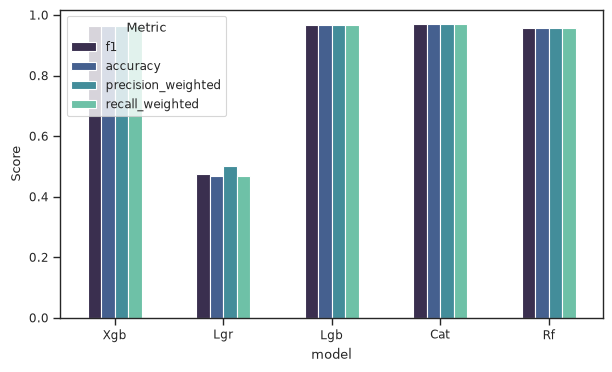

In [12]:
df_long = model_bench.melt(id_vars="model",
                var_name="Metric",
                value_name="Score")

plt.figure(figsize=(7,4))
sns.barplot(
    data=df_long,
    x="model",
    y="Score",
    hue="Metric",
    palette="mako",
    width=0.5
)

plt.show()

**Analysis of the baseline experiment**

The first experiment aimed to establish a baseline comparison between five machine learning algorithms for multiclass epileptic seizure classification using their default hyperparameters. The evaluated models included Logistic Regression, Random Forest, XGBoost, LightGBM, and CatBoost.

The results indicate that the ensemble tree-based models consistently outperformed the linear model. CatBoost achieved the highest performance, obtaining an accuracy of 96.88% and a weighted F1-score of 96.88%, closely followed by LightGBM (96.67%) and XGBoost (96.42%). Random Forest also demonstrated strong performance, achieving an accuracy of 95.83% and a weighted F1-score of 95.84%. In contrast, Logistic Regression produced considerably lower results, with an accuracy of 46.83% and a weighted F1-score of 47.52%.

The superior performance of the gradient boosting models suggests that the relationships between the EEG features and seizure classes are highly nonlinear. Unlike Logistic Regression, which assumes linear decision boundaries, ensemble methods are capable of learning complex feature interactions and nonlinear patterns, enabling them to better discriminate between the four seizure categories.

Another important observation is the negligible difference between the accuracy and weighted F1-score for the tree-based models. Since the weighted F1-score combines both precision and recall while accounting for the class distribution, its close agreement with the accuracy indicates that the models maintain a balanced performance across all classes rather than achieving high accuracy by favoring a particular class.

Based on these results, CatBoost, LightGBM, and XGBoost were selected for further evaluation. These three models consistently achieved the highest predictive performance and therefore represent the most promising candidates for subsequent experiments involving cross-validation and hyperparameter optimization.

##### **04. Models performance stability:**
To test the models preformance statbility we will run a cross validation experiment where we test the models accross the data :

In [9]:
import wandb as wb
import pandas as pd

PROJECT_NAME = "Epeliptic_seizure_classification"
GROUP_NAME = "Baseline-comparison-v1"

models = {
    "Xgb": XGBClassifier(random_state=42),
    "Lgb": LGBMClassifier(random_state=42, verbosity=-1),
    "Cat": CatBoostClassifier(random_state=42, verbose=False),
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cross_scores = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="f1_weighted"
    )

    cross_scores.append({
        "model": name,
        "Mean_f1": scores.mean(),
        "Std_f1": scores.std()
    })

run = wb.init(
    project=PROJECT_NAME,
    name="cross_val",
    group=GROUP_NAME,
    job_type="stability_test"
)

cv_results = wb.Table(dataframe=pd.DataFrame(cross_scores))
run.log({"cross_validation_summary": cv_results})

run.finish()

In [10]:
pd.DataFrame(cross_scores)

,model,Mean_f1,Std_f1
0,Xgb,0.969076,0.002951
1,Lgb,0.968334,0.004421
2,Cat,0.973292,0.003650


The table above presents the results of the three models selected from the first experiment after applying 5-fold cross-validation to evaluate the stability of their performance. The results indicate that the weighted F1-score remains highly consistent across the five folds, with only marginal variations ranging from 0.002 to 0.004. This low standard deviation demonstrates that the models generalize well and produce stable performance across different subsets of the dataset.

#### **05. Hyperparms tunning:**

In [ ]:


models = {
    "Xgb":XGBClassifier(random_state=42,**param_dist_xgb),
    "Lgb":LGBMClassifier(random_state=42,verbosity=-1,**param_dist_lgb),
    "Cat":CatBoostClassifier(random_state=42,verbose=False,**param_dist_cat)
}


In [35]:
class HyperparameterOptimizer():
    def __init__(
        self,
        model_name,
        model_class,
        search_space,
        x_train,
        x_test,
        x_val ,
        y_val ,
        y_train,
        y_test,
        project_name,
        group_name,
        random_state=42
    ):
        self.model_name =model_name 
        self.model_class = model_class
        self.search_space = search_space

        self.x_train = x_train
        self.x_test = x_test

        self.x_val = x_val
        self.y_val = y_val

        self.y_train = y_train
        self.y_test = y_test
        
        self.project_name = project_name
        self.group_name = group_name
        self.random_state = random_state
        self.study = None 
        self.best_model = None
        self.wb_run = None
    
    def wandb_init(self):

        self.wb_run = wb.init(
            project=self.project_name,
            name = f"{self.model_name}_v1",
            notes = "Optimisation with optuna",
            group = self.group_name,
            job_type = "Hyperparameter_Optimization",
            reinit=True
            )
        

    def objective(self,trial):
        params = {}

        for param_name, spec in self.search_space.items():

            if spec[0] == 'int':
                params[param_name] = trial.suggest_int(
                    param_name,
                    spec[1],
                    spec[2]
                    )

            elif spec[0] == 'float':
                params[param_name] = trial.suggest_float(
                    param_name,
                    spec[1],
                    spec[2]
                    )
            
            elif spec[0] == "categorical":
                params[param_name] = trial.suggest_categorical(
                    param_name,
                    spec[1]
                )
        
        model = self.model_class(
            random_state=self.random_state,
            **params

        )

        model.fit(
            self.x_train,
            self.y_train,
        )

        pred = model.predict(self.x_val)

        score = f1_score(
            self.y_val,
            pred,
            average="weighted"
        )

        return score
    
    def optimize(self, n_trials=20):

        self.study = optuna.create_study(
            study_name=self.model_name,
            direction="maximize"
        )

        self.study.optimize(
            self.objective,
            n_trials=n_trials
        )
    def train_best_model(self):

        self.best_model = self.model_class(
            random_state=42,
            **self.study.best_params
        )
        self.best_model.fit(
            self.x_train,
            self.y_train
        )

    def evaluate(self):
        preds = self.best_model.predict(self.x_test)

        metrics = {
        "accuracy": accuracy_score(self.y_test, preds ),
        "f1": f1_score(self.y_test, preds , average="weighted"),
        "precision": precision_score(self.y_test, preds , average="weighted"),
        "recall": recall_score(self.y_test, preds , average="weighted"),
        }

        return metrics 

    def save_model(self):
        model_path = f"{self.model_name}_v1.joblib"
        joblib.dump(
            self.best_model,
            model_path
        )
        return model_path 

    def log_wandb(self,metrics,model_path):
        artifact = wb.Artifact(
        name=f"{self.model_name}_v1",
        type="model",
        description=f"{self.model_name} after hyperparamter tunning using optuna",
        metadata=metrics
        )
        artifact.add_file(model_path)
        self.wb_run.log_artifact(artifact)
        self.wb_run.log(metrics)
        self.wb_run.log({
        "best_cv_score": self.study.best_value
        })
        self.wb_run.finish()

    def run(self):
        self.wandb_init()
        self.optimize()
        self.train_best_model()
        metrics = self.evaluate()
        model_path = self.save_model()
        self.log_wandb(metrics,model_path)

        return metrics


In [14]:
X_train, x_val , Y_train , y_val = train_test_split(x_train,y_train,test_size=0.3,random_state=42)

In [17]:
x_train.shape, x_val.shape , y_test.shape, y_val.shape 

((5600, 16), (1680, 16), (2400,), (1680,))

In [37]:
xgb_search_space = {
    "n_estimators": ("int", 100, 800),
    "max_depth": ("int", 3, 10),
    "learning_rate": ("float", 0.01, 0.3),
    "subsample": ("float", 0.6, 1.0),
    "colsample_bytree": ("float", 0.6, 1.0),
    "min_child_weight": ("int", 1, 10),
    "gamma": ("float", 0.0, 5.0),
    "reg_alpha": ("float", 0.0, 5.0),
    "reg_lambda": ("float", 0.0, 10.0),
}

lgbm_search_space = {
    "n_estimators": ("int", 100, 800),
    "learning_rate": ("float", 0.01, 0.3),
    "max_depth": ("int", 3, 10),
    "num_leaves": ("int", 15, 150),
    "min_child_samples": ("int", 5, 50),
    "subsample": ("float", 0.6, 1.0),
    "colsample_bytree": ("float", 0.6, 1.0),
    "reg_alpha": ("float", 0.0, 5.0),
    "reg_lambda": ("float", 0.0, 10.0),
}

catboost_search_space = {
    "iterations": ("int", 100, 800),
    "depth": ("int", 4, 10),
    "learning_rate": ("float", 0.01, 0.3),
    "l2_leaf_reg": ("float", 1.0, 10.0),
    "random_strength": ("float", 0.0, 5.0),
    "bagging_temperature": ("float", 0.0, 5.0),
    "border_count": ("int", 32, 255),
}

models = {
    "XGB": {
        "class": XGBClassifier,
        "search_space": xgb_search_space
    },
    "LGBM": {
        "class": LGBMClassifier,
        "search_space": lgbm_search_space
    }#,
    # "CAT": {
    #     "class": CatBoostClassifier,
    #     "search_space": catboost_search_space
    # }
}

for model_name , scp in models.items():
    optimizer = HyperparameterOptimizer(
        model_name=model_name,
        model_class=scp["class"],
        search_space=scp["search_space"],
        x_train=X_train,
        x_test=x_test,
        x_val=x_val,
        y_val=y_val,
        y_train=Y_train,
        y_test=y_test,
        project_name=PROJECT_NAME,
        group_name=GROUP_NAME,
    )
    metrics = optimizer.run()
    print(model_name)
    print(metrics)

[I 2026-07-26 00:01:41,005] A new study created in memory with name: XGB
[I 2026-07-26 00:01:41,835] Trial 0 finished with value: 0.840479607385974 and parameters: {'n_estimators': 204, 'max_depth': 5, 'learning_rate': 0.16186979887519204, 'subsample': 0.6430147973899979, 'colsample_bytree': 0.7892965317519927, 'min_child_weight': 3, 'gamma': 3.5831544821716226, 'reg_alpha': 3.0889873053226493, 'reg_lambda': 5.282083415170483}. Best is trial 0 with value: 0.840479607385974.
[I 2026-07-26 00:01:42,876] Trial 1 finished with value: 0.9224265396316874 and parameters: {'n_estimators': 554, 'max_depth': 10, 'learning_rate': 0.20398051906648268, 'subsample': 0.901456948084302, 'colsample_bytree': 0.8691586421658698, 'min_child_weight': 1, 'gamma': 0.7911781764199599, 'reg_alpha': 1.1375584417910123, 'reg_lambda': 2.31574488347552}. Best is trial 1 with value: 0.9224265396316874.
[I 2026-07-26 00:01:42,335] Trial 2 finished with value: 0.856723222598832 and parameters: {'n_estimators': 363, '

accuracy,▁
best_cv_score,▁
f1,▁
precision,▁
recall,▁
accuracy,0.94417
best_cv_score,0.96316
f1,0.94424
precision,0.94433
recall,0.94417


XGB
{'accuracy': 0.9441666666666667, 'f1': 0.9442421618047186, 'precision': 0.9443305069337697, 'recall': 0.9441666666666667}


[I 2026-07-26 00:02:21,841] A new study created in memory with name: LGBM
[I 2026-07-26 00:02:22,452] Trial 0 finished with value: 0.9542061952204477 and parameters: {'n_estimators': 620, 'learning_rate': 0.2776502384374058, 'max_depth': 5, 'num_leaves': 130, 'min_child_samples': 33, 'subsample': 0.6367498693212204, 'colsample_bytree': 0.791319839217383, 'reg_alpha': 0.7416801200460515, 'reg_lambda': 8.281161529780059}. Best is trial 0 with value: 0.9542061952204477.
[I 2026-07-26 00:02:22,621] Trial 1 finished with value: 0.9089481456898513 and parameters: {'n_estimators': 592, 'learning_rate': 0.1657961732245161, 'max_depth': 3, 'num_leaves': 45, 'min_child_samples': 44, 'subsample': 0.8346377084753369, 'colsample_bytree': 0.7860713535405872, 'reg_alpha': 4.5886109399843065, 'reg_lambda': 2.564375386452331}. Best is trial 0 with value: 0.9542061952204477.
[I 2026-07-26 00:02:22,705] Trial 2 finished with value: 0.8986985784233423 and parameters: {'n_estimators': 139, 'learning_rate':

accuracy,▁
best_cv_score,▁
f1,▁
precision,▁
recall,▁
accuracy,0.95083
best_cv_score,0.96431
f1,0.9509
precision,0.95097
recall,0.95083


LGBM
{'accuracy': 0.9508333333333333, 'f1': 0.9508955979140509, 'precision': 0.9509685060076745, 'recall': 0.9508333333333333}
